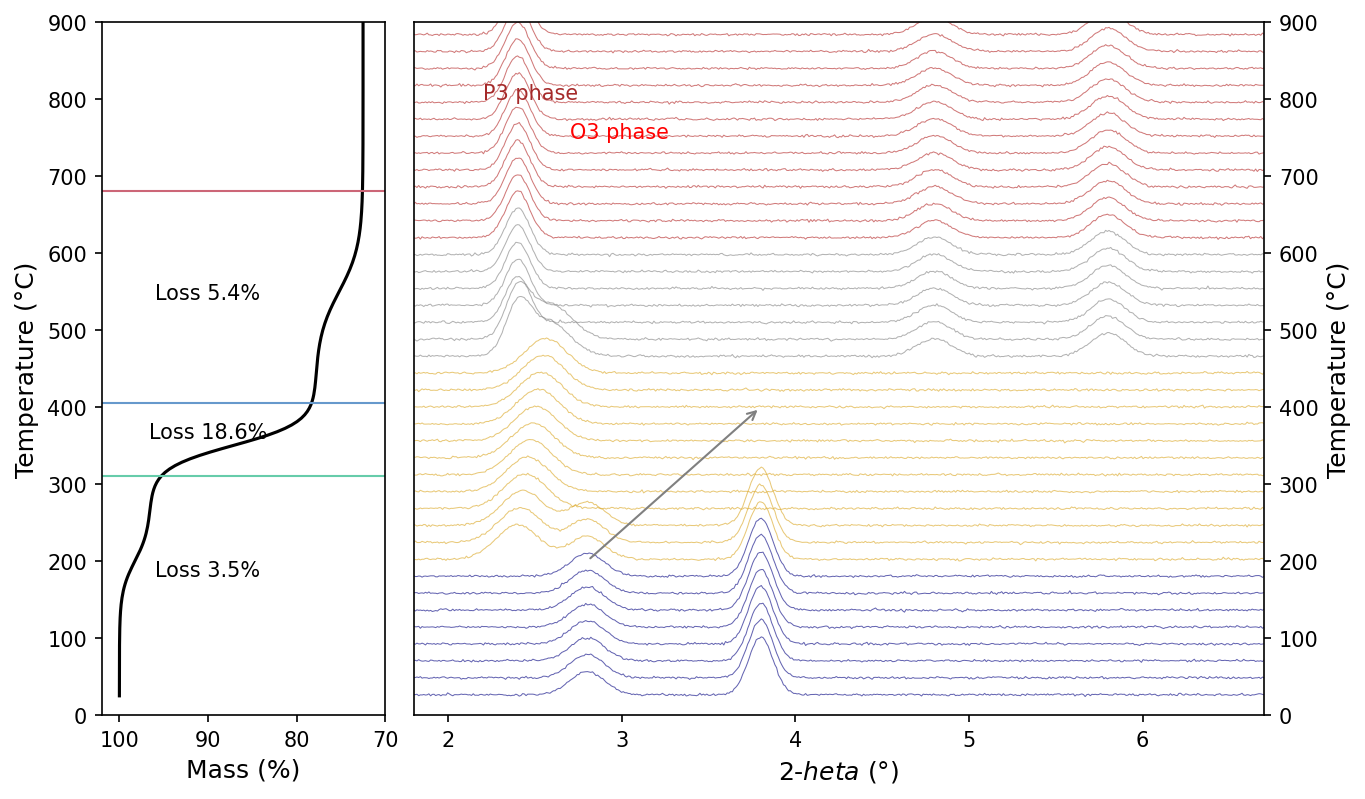

In [1]:
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import numpy as np

# --- Data Simulation ---
temp = np.linspace(25, 900, 200)

# TGA Data (Left)
# Mass loss steps
mass = np.ones_like(temp) * 100
# Step 1: 100-300C, loss 3.5%
mass -= 3.5 / (1 + np.exp(-(temp - 200)/20))
# Step 2: 300-400C, loss 18.6%
mass -= 18.6 / (1 + np.exp(-(temp - 350)/15))
# Step 3: 400-700C, loss 5.4%
mass -= 5.4 / (1 + np.exp(-(temp - 550)/30))

# XRD Data (Right)
two_theta = np.linspace(1.8, 6.7, 500)
# Create many scans at different temperatures
scans = []
for t in temp[::5]: # Downsample for waterfall
    # Simulate peaks shifting/appearing
    y = np.zeros_like(two_theta) + 0.1 # Baseline

    # Phase 1 (Low T): Precursor (Blue peaks)
    if t < 250:
        y += 2.0 * np.exp(-((two_theta - 2.8)**2)/0.02) # (003)
        y += 5.0 * np.exp(-((two_theta - 3.8)**2)/0.01) # (006)

    # Phase 2 (Mid T): Decomposition (Yellow/Orange)
    if 200 < t < 500:
        # Shifting peak 2.4 -> 2.6
        pos = 2.4 + 0.2 * (t - 200)/300
        y += 3.0 * np.exp(-((two_theta - pos)**2)/0.03)

    # Phase 3 (High T): O3 Phase (Red)
    if t > 450:
        y += 4.0 * np.exp(-((two_theta - 2.4)**2)/0.01) # Sharp (003)
        y += 1.5 * np.exp(-((two_theta - 4.8)**2)/0.02)
        y += 2.0 * np.exp(-((two_theta - 5.8)**2)/0.02)

    # Noise
    y += np.random.normal(0, 0.05, len(two_theta))
    scans.append(y)

scans_temp = temp[::5]

# --- Plotting ---
fig = plt.figure(figsize=(10, 6), dpi=150)
gs = gridspec.GridSpec(1, 2, width_ratios=[1, 3], wspace=0.05)

# Left Panel: TGA
ax1 = fig.add_subplot(gs[0])
ax1.plot(mass, temp, 'k-')
ax1.set_xlabel('Mass (%)', fontsize=12)
ax1.set_ylabel('Temperature (°C)', fontsize=12)
ax1.set_ylim(0, 900)
ax1.set_xlim(70, 102)
ax1.invert_xaxis()
# Add horizontal lines
ax1.hlines([310, 405, 680], 70, 102, colors=['#66CCAA', '#6699CC', '#CC6677'], lw=1)
ax1.text(90, 180, 'Loss 3.5%', ha='center')
ax1.text(90, 360, 'Loss 18.6%', ha='center')
ax1.text(90, 540, 'Loss 5.4%', ha='center')

# Right Panel: Waterfall XRD
ax2 = fig.add_subplot(gs[1], sharey=ax1)
offset_scale = 10 # Scale intensity to temperature axis units?
# Actually, waterfall usually adds offset to Y. Since Y is Temp, we add signal * scale to Temp.
# But here X is 2theta, Y is Temp.
# The signal peaks point to the RIGHT (along X)? No, they point UP in Z, but plotted as lines.
# In a 2D waterfall where Y is variable (Temp), intensity is usually added to Y.
# Let's check image: Peaks point UP (Temperature axis).
# So: Plot(two_theta, temp + intensity)

for i, y_scan in enumerate(scans):
    t_val = scans_temp[i]
    # Color based on temp/phase
    col = 'gray'
    if t_val < 200: col = 'navy'
    elif t_val < 450: col = 'goldenrod'
    elif t_val > 600: col = 'firebrick'

    # Plot line
    # Scale intensity to match visual height
    ax2.plot(two_theta, t_val + y_scan * 15, color=col, lw=0.5, alpha=0.6)

ax2.set_xlabel(r'2-$	heta$ (°)', fontsize=12)
ax2.set_xlim(1.8, 6.7)
ax2.yaxis.tick_right()
ax2.yaxis.set_label_position("right")
ax2.set_ylabel('Temperature (°C)', fontsize=12)

# Arrows and Labels (Simplified)
ax2.text(2.2, 800, 'P3 phase', color='brown', fontsize=10)
ax2.text(2.7, 750, 'O3 phase', color='red', fontsize=10)
ax2.annotate('', xy=(3.8, 400), xytext=(2.8, 200), arrowprops=dict(arrowstyle='->', color='gray'))

plt.show()


C:\Users\julia\AppData\Local\Temp\ipykernel_35084\1681981740.py:235: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


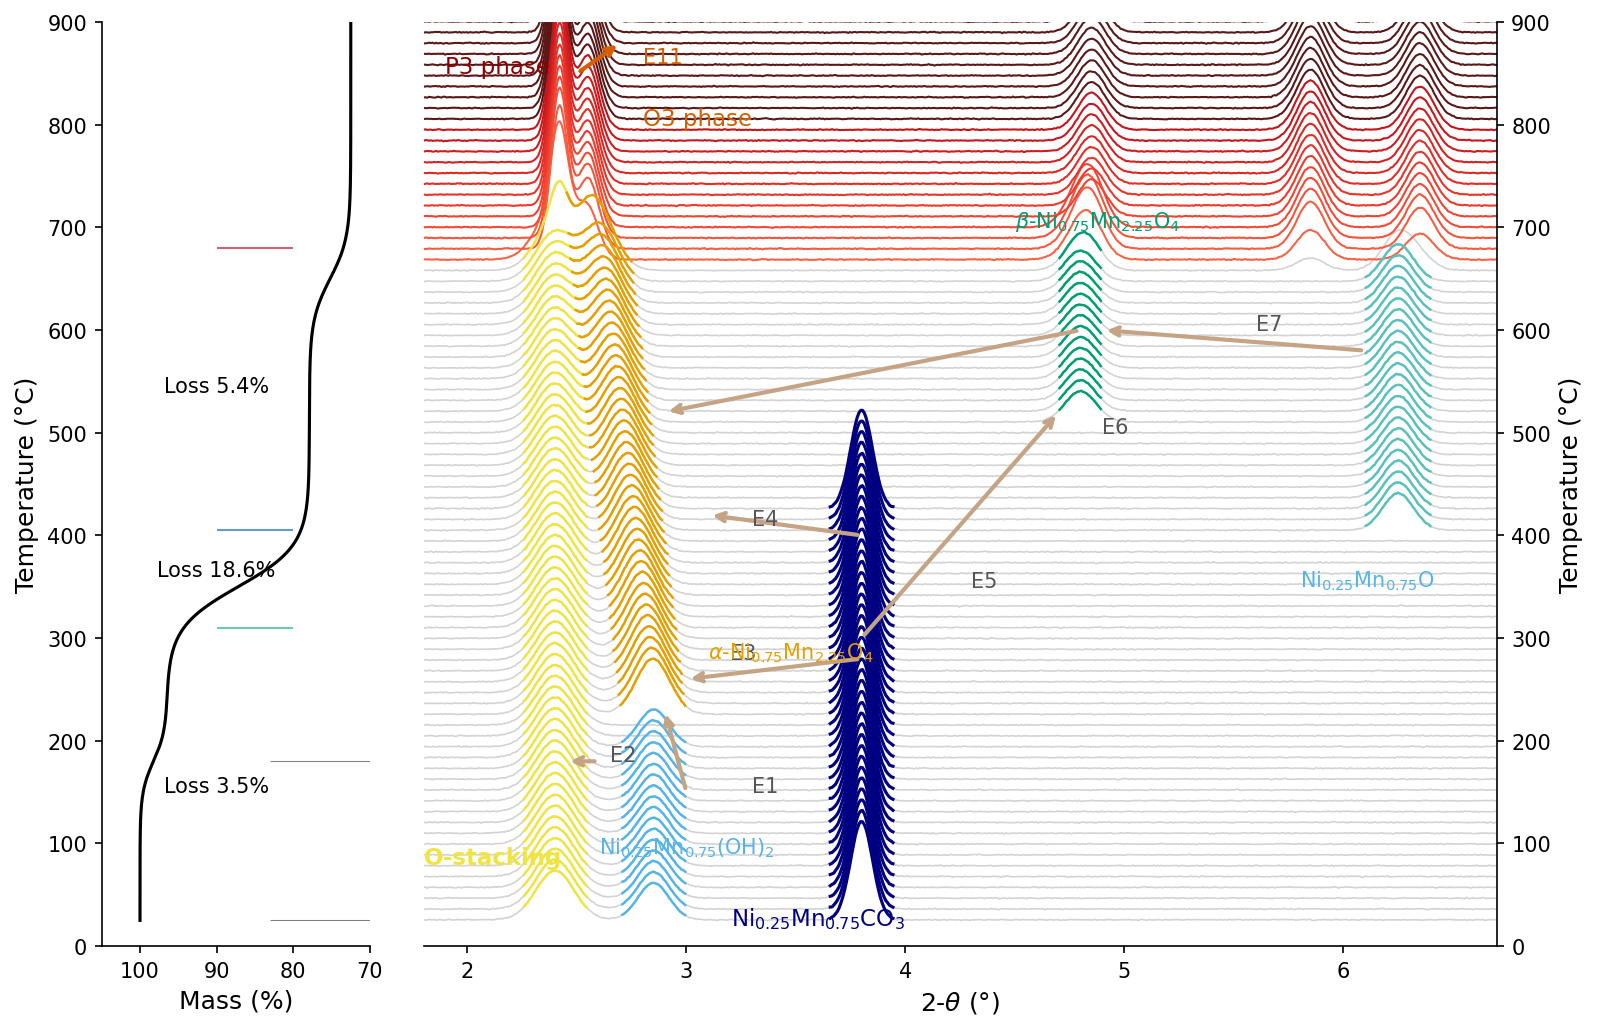

In [2]:
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import numpy as np

# --- Data Simulation ---
temp = np.linspace(25, 900, 250) # More resolution

# TGA Data (Left)
# Mass loss steps
mass = np.ones_like(temp) * 100
# Step 1: ~150-200C, loss 3.5%
mass -= 3.5 / (1 + np.exp(-(temp - 180)/15))
# Step 2: ~300-400C, loss 18.6%
mass -= 18.6 / (1 + np.exp(-(temp - 350)/20))
# Step 3: ~600-700C, loss 5.4%
mass -= 5.4 / (1 + np.exp(-(temp - 650)/20))

# XRD Data (Right)
two_theta = np.linspace(1.8, 6.7, 600)
scans = []
scans_temp = []

# Downsample for waterfall visual
for i, t in enumerate(temp):
    if i % 3 != 0: continue # Plot every 3rd step
    scans_temp.append(t)

    y = np.zeros_like(two_theta) + 0.05 # Baseline

    # --- Define Peaks based on visual analysis ---

    # 1. Dark Blue Peak (Ni0.25Mn0.75CO3) - ~3.8 deg, T < 420
    if t < 430:
        # Sharp, intense
        y += 8.0 * np.exp(-((two_theta - 3.8)**2)/0.005)

    # 2. Yellow Peak (O-stacking) - ~2.4 deg, T < 660
    if t < 670:
        # Broader
        y += 4.0 * np.exp(-((two_theta - 2.4)**2)/0.015)

    # 3. Light Blue Peak (Ni0.25Mn0.75(OH)2) - ~2.8 deg, T < 180
    if t < 200:
         y += 3.0 * np.exp(-((two_theta - 2.85)**2)/0.01)

    # 4. Orange Peak (alpha-NiMn...) - Moving 2.8 -> 2.6, 220 < T < 650
    if 220 < t < 660:
        # Shift calculation: 0 at 220, 1 at 660
        progress = (t - 220) / (660 - 220)
        pos = 2.85 - (0.25 * progress)
        y += 4.5 * np.exp(-((two_theta - pos)**2)/0.012)

    # 5. Cyan Peak (NiMn O) - ~6.2 deg, 400 < T < 650
    if 400 < t < 660:
        y += 3.0 * np.exp(-((two_theta - 6.25)**2)/0.01)

    # 6. Green Peak (beta-NiMn...) - ~4.8 deg, 500 < T < 700
    if 500 < t < 700:
        y += 2.5 * np.exp(-((two_theta - 4.8)**2)/0.01)

    # 7. High T Phase (O3/P3) - T > 660
    if t > 650:
        # Transition effects
        factor = min(1.0, (t - 650)/30)

        # Doublet at low angle
        y += factor * 12.0 * np.exp(-((two_theta - 2.42)**2)/0.003) # Sharp P3
        y += factor * 6.0 * np.exp(-((two_theta - 2.55)**2)/0.005) # O3 shoulder

        y += factor * 3.0 * np.exp(-((two_theta - 4.85)**2)/0.008)
        y += factor * 4.0 * np.exp(-((two_theta - 5.85)**2)/0.008)
        y += factor * 3.5 * np.exp(-((two_theta - 6.35)**2)/0.008)

    # Noise
    y += np.random.normal(0, 0.02, len(two_theta))
    scans.append(y)


# --- Plotting ---
fig = plt.figure(figsize=(12, 8), dpi=150)
gs = gridspec.GridSpec(1, 2, width_ratios=[1, 4], wspace=0.08)

# === Left Panel: TGA ===
ax1 = fig.add_subplot(gs[0])
ax1.plot(mass, temp, 'k-', lw=1.5)
ax1.set_xlabel('Mass (%)', fontsize=12)
ax1.set_ylabel('Temperature (°C)', fontsize=12)
ax1.set_ylim(0, 900)
ax1.set_xlim(70, 105)
ax1.invert_xaxis()

# Spines
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Horizontal lines & Text
# 3.5% Loss (~180C)
ax1.hlines([25, 180], 70, 83, colors='gray', lw=0.5) # Bounds? No, just lines indicating steps
# The image has lines AT the step transitions or indicating the delta.
# Let's match the image: Green line at ~310, Blue at ~405, Pink at ~680.
ax1.hlines(310, 80, 90, colors='#66CCAA', lw=1)
ax1.hlines(405, 80, 90, colors='#6699CC', lw=1)
ax1.hlines(680, 80, 90, colors='#CC6677', lw=1)

ax1.text(90, 150, 'Loss 3.5%', ha='center', fontsize=10)
ax1.text(90, 360, 'Loss 18.6%', ha='center', fontsize=10)
ax1.text(90, 540, 'Loss 5.4%', ha='center', fontsize=10)


# === Right Panel: XRD Waterfall ===
ax2 = fig.add_subplot(gs[1], sharey=ax1)
ax2.spines['top'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax2.spines['right'].set_visible(True)
ax2.yaxis.tick_right()
ax2.yaxis.set_label_position("right")
ax2.set_ylabel('Temperature (°C)', fontsize=12)
ax2.set_xlabel(r'2-$\theta$ (°)', fontsize=12)
ax2.set_xlim(1.8, 6.7)

# Helper to scale intensity
y_scale = 12

# Plot Loop
for i, y_scan in enumerate(scans):
    t_val = scans_temp[i]
    base_y = t_val + y_scan * y_scale

    # 1. Base Line (Grey or Red/Brown for High T)
    if t_val < 660:
        color = '#D3D3D3' # LightGray
        lw = 0.8
        zorder = 1
    else:
        # Gradient from Red to Dark Brown
        norm_t = (t_val - 660) / (900 - 660)
        color = plt.cm.Reds(0.5 + 0.5 * norm_t) # Start mid-red, go dark
        if t_val > 800: color = '#5a1919' # Dark brown
        lw = 1.0
        zorder = 2

    ax2.plot(two_theta, base_y, color=color, lw=lw, zorder=zorder)

    # 2. Highlight Zones (Selective Coloring)
    if t_val < 660:
        # Yellow Zone (2.3 - 2.5)
        if t_val < 660:
            mask = (two_theta > 2.25) & (two_theta < 2.55)
            ax2.plot(two_theta[mask], base_y[mask], color='#F0E442', lw=1.2, zorder=3) # Yellow

        # Dark Blue Zone (3.7 - 3.9) - Peak 1
        if t_val < 430:
            mask = (two_theta > 3.65) & (two_theta < 3.95)
            ax2.plot(two_theta[mask], base_y[mask], color='#000080', lw=1.5, zorder=3) # Navy

        # Light Blue Zone (2.7 - 2.95) - Peak 3
        if t_val < 200:
            mask = (two_theta > 2.7) & (two_theta < 3.0)
            ax2.plot(two_theta[mask], base_y[mask], color='#56B4E9', lw=1.2, zorder=3) # Light Blue

        # Orange Zone (Moving Peak 4)
        if 220 < t_val < 660:
            # Calculate center again to mask correctly
            progress = (t_val - 220) / (660 - 220)
            center = 2.85 - (0.25 * progress)
            mask = (two_theta > center - 0.15) & (two_theta < center + 0.15)
            ax2.plot(two_theta[mask], base_y[mask], color='#E69F00', lw=1.2, zorder=3) # Orange

        # Cyan Zone (6.1 - 6.4) - Peak 5
        if 400 < t_val < 650:
            mask = (two_theta > 6.1) & (two_theta < 6.4)
            ax2.plot(two_theta[mask], base_y[mask], color='#5CC0C0', lw=1.2, zorder=3) # Cyan/Teal

        # Green Zone (4.7 - 4.9) - Peak 6
        if 500 < t_val < 690:
            mask = (two_theta > 4.7) & (two_theta < 4.9)
            ax2.plot(two_theta[mask], base_y[mask], color='#009E73', lw=1.2, zorder=3) # Green


# --- Annotations & Arrows ---

# Helper for Arrows
def add_arrow(ax, start, end, text=None, text_pos=None, color='#C4A484'):
    ax.annotate('', xy=end, xytext=start,
                arrowprops=dict(arrowstyle='->', color=color, lw=2))
    if text and text_pos:
        ax.text(text_pos[0], text_pos[1], text, fontsize=10, color='#555555')

# E1: Blue -> Orange transition
add_arrow(ax2, (3.0, 150), (2.9, 230))
ax2.text(3.3, 150, 'E1', color='#555555')

# E2: Yellow Base
add_arrow(ax2, (2.6, 180), (2.45, 180))
ax2.text(2.65, 180, 'E2', color='#555555')

# E3: Dark Blue -> Orange
add_arrow(ax2, (3.8, 280), (3.0, 260))
ax2.text(3.2, 280, 'E3', color='#555555')

# E4: Dark Blue -> Orange (Higher)
add_arrow(ax2, (3.8, 400), (3.1, 420))
ax2.text(3.3, 410, 'E4', color='#555555')

# E5: Dark Blue -> Green
add_arrow(ax2, (3.8, 300), (4.7, 520))
ax2.text(4.3, 350, 'E5', color='#555555')

# E6: Green -> Orange
add_arrow(ax2, (4.8, 600), (2.9, 520))
ax2.text(4.9, 500, 'E6', color='#555555')

# E7: Cyan -> Green
add_arrow(ax2, (6.1, 580), (4.9, 600))
ax2.text(5.6, 600, 'E7', color='#555555')

# E11: High T Transition
add_arrow(ax2, (2.5, 850), (2.7, 880), color='#D55E00') # Reddish
ax2.text(2.8, 860, 'E11', color='#D55E00')


# Chemical Labels
ax2.text(1.8, 80, 'O-stacking', color='#F0E442', fontsize=11, fontweight='bold')
ax2.text(3.6, 20, r'Ni$_{0.25}$Mn$_{0.75}$CO$_3$', color='#000080', fontsize=11, ha='center')
ax2.text(2.6, 90, r'Ni$_{0.25}$Mn$_{0.75}$(OH)$_2$', color='#56B4E9', fontsize=10)
ax2.text(3.1, 280, r'$\alpha$-Ni$_{0.75}$Mn$_{2.25}$O$_4$', color='#E69F00', fontsize=10)
ax2.text(4.5, 700, r'$\beta$-Ni$_{0.75}$Mn$_{2.25}$O$_4$', color='#009E73', fontsize=10)
ax2.text(5.8, 350, r'Ni$_{0.25}$Mn$_{0.75}$O', color='#56B4E9', fontsize=10)

ax2.text(1.9, 850, 'P3 phase', color='#8B0000', fontsize=11)
ax2.text(2.8, 800, 'O3 phase', color='#D55E00', fontsize=11)


plt.tight_layout()
plt.show()

